In [1]:
# ============================================
# 1. Imports and global configuration
# ============================================

from pathlib import Path
import json
import itertools
import warnings

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kruskal, chi2_contingency
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
TOP_K = 10

In [2]:
# ============================================
# 2. Paths
# ============================================

BASE_DIR = Path("../../results/").resolve()

RESULTS_FILE = BASE_DIR / "clustering_exploration/tables/clustering_exploration_results.csv"
LABEL_INDEX_FILE = BASE_DIR / "clustering_exploration/tables/clustering_label_index.csv"
DATA_FILE = BASE_DIR / "processed_hrv/basal_v2_clean_with_categories.csv"
METADATA_FILE = BASE_DIR / "clustering_exploration/metadata/clustering_exploration_metadata.json"

LABEL_BASE_DIR = BASE_DIR / "clustering_exploration/labels/"

In [3]:
# ============================================
# 3. Load data
# ============================================

results_df = pd.read_csv(RESULTS_FILE)
label_index_df = pd.read_csv(LABEL_INDEX_FILE)
data_df = pd.read_csv(DATA_FILE)

with open(METADATA_FILE, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("results_df", results_df.shape)
print("label_index_df", label_index_df.shape)
print("data_df", data_df.shape)
print("n_subjects metadata", metadata["n_subjects"])
print("n_input_spaces metadata", metadata["n_input_spaces"])
print("n_total_experiments metadata", metadata["n_total_experiments"])

results_df (24168, 18)
label_index_df (24168, 6)
data_df (530, 29)
n_subjects metadata 530
n_input_spaces metadata 38
n_total_experiments metadata 24168


In [4]:
# ============================================
# 4. Variable definition
# ============================================

HRV_VARS = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

EXT_CONT_VARS = [
    "age",
    "weight_kg",
    "height_m_final",
    "imc_final",
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

EXT_CAT_VARS = [
    "sex",
    "age_group",
    "bmi_cat",
    "bp_cat",
]

ALL_EXT_VARS = EXT_CONT_VARS + EXT_CAT_VARS

missing_hrv = [c for c in HRV_VARS if c not in data_df.columns]
missing_ext = [c for c in ALL_EXT_VARS if c not in data_df.columns]

print("Missing HRV vars:", missing_hrv)
print("Missing external vars:", missing_ext)

Missing HRV vars: []
Missing external vars: []


In [5]:
# ============================================
# 5. Basic data cleaning for evaluation
# ============================================

eval_df = data_df.copy()

# Opcional. Si quieres una limpieza más estricta, la ajustamos luego.
# Por ahora solo reemplazamos infinitos por NaN.
eval_df = eval_df.replace([np.inf, -np.inf], np.nan)

# Asegurar índice alineado con labels
eval_df = eval_df.reset_index(drop=True)

print(eval_df.shape)
eval_df.head()

(530, 29)


,sex,age,weight_kg,height_cm_final,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp,bp_pp_recomputed,bp_pam_recomputed,t2m_pre_mean_rr,t2m_pre_mean_hr,t2m_pre_sdnn,t2m_pre_rmssd,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf,mean_hr_from_rr,height_inconsistent,imc_inconsistent,hr_rr_inconsistent,n_integrity_flags,n_range_flags,n_total_qc_flags,age_group,bmi_cat,bp_cat
0,1,75,70.0,160.0,1.60,27.343750,108,70,82.666667,38,38,82.666667,748.0,80.0,308.0,21.7,222,713,172,80.213904,False,False,False,0,0,0,70-79,normal,normal
1,1,66,52.0,149.0,1.49,23.422368,122,72,88.666667,50,50,88.666667,953.0,63.0,255.0,18.8,87,226,29,62.959077,False,False,False,0,0,0,60-69,normal,normal
2,2,77,81.0,170.0,1.70,28.027682,125,85,98.333333,40,40,98.333333,877.0,68.0,147.0,11.7,26,137,9,68.415051,False,False,False,0,0,0,70-79,overweight,normal
3,1,77,85.0,160.0,1.60,33.203125,126,72,90.000000,54,54,90.000000,819.0,73.0,170.0,17.5,118,130,14,73.260073,False,False,False,0,0,0,70-79,obesity,normal
4,1,73,69.0,151.0,1.51,30.261831,130,80,96.666667,50,50,96.666667,846.0,71.0,176.0,13.6,66,66,18,70.921986,False,False,False,0,0,0,70-79,overweight,normal


In [6]:
# ============================================
# 6. Helper functions
# ============================================

def safe_minmax(series: pd.Series) -> pd.Series:
    x = series.astype(float).copy()
    if x.nunique(dropna=True) <= 1:
        return pd.Series(np.zeros(len(x)), index=x.index, dtype=float)
    scaler = MinMaxScaler()
    vals = scaler.fit_transform(x.values.reshape(-1, 1)).ravel()
    return pd.Series(vals, index=x.index, dtype=float)


def safe_minmax_inverted(series: pd.Series) -> pd.Series:
    return 1.0 - safe_minmax(series)


def resolve_label_path(label_file: str, label_base_dir: Path) -> Path:
    p = Path(label_file)
    if p.exists():
        return p.resolve()
    # Si viene relativa al notebook original
    candidate = (label_base_dir / p.name).resolve()
    return candidate


def get_cluster_counts(labels: np.ndarray) -> pd.Series:
    labels = np.asarray(labels)
    valid = labels[labels != -1]
    if len(valid) == 0:
        return pd.Series(dtype=int)
    return pd.Series(valid).value_counts().sort_index()


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    m = np.isfinite(values) & np.isfinite(weights)
    if m.sum() == 0 or weights[m].sum() == 0:
        return np.nan
    return np.average(values[m], weights=weights[m])


def normalize_score(x, lower_better=False):
    s = pd.Series(x).astype(float)
    if lower_better:
        return safe_minmax_inverted(s)
    return safe_minmax(s)

In [7]:
# ============================================
# 7. Structural hard filters
# ============================================

def apply_hard_filters(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["pass_k"] = out["n_clusters"].between(4, 10, inclusive="both")
    out["pass_min_cluster"] = out["min_cluster_size"] >= 10
    out["pass_noise"] = out["noise_fraction"] <= 0.50
    out["pass_silhouette"] = out["silhouette"] >= 0.0
    out["pass_max_cluster_fraction"] = (out["max_cluster_size"] / metadata["n_subjects"]) <= 0.75

    out["pass_all_filters"] = (
        out["pass_k"] &
        out["pass_min_cluster"] &
        out["pass_noise"] &
        out["pass_silhouette"] &
        out["pass_max_cluster_fraction"]
    )
    return out

filtered_df = apply_hard_filters(results_df)

print(filtered_df["pass_all_filters"].value_counts(dropna=False))
print(filtered_df.loc[filtered_df["pass_all_filters"]].shape)

pass_all_filters
False    17527
True      6641
Name: count, dtype: int64
(6641, 24)


In [8]:
# ============================================
# 8. Structural score
# ============================================

def compute_k_penalty(k: int) -> int:
    # 0 para rango preferido 5-8
    # 1 para rango aceptable 4 o 9-10
    if 5 <= k <= 8:
        return 0
    if k == 4 or (9 <= k <= 10):
        return 1
    return np.nan


struct_df = filtered_df.loc[filtered_df["pass_all_filters"]].copy()

struct_df["k_penalty"] = struct_df["n_clusters"].apply(compute_k_penalty)

struct_df["sil_norm"] = normalize_score(struct_df["silhouette"], lower_better=False)
struct_df["db_norm"] = normalize_score(struct_df["davies_bouldin"], lower_better=True)
struct_df["ch_norm"] = normalize_score(struct_df["calinski_harabasz"], lower_better=False)
struct_df["noise_norm"] = normalize_score(struct_df["noise_fraction"], lower_better=True)

# Penalización explícita como 0 o 1, luego la usamos en la fórmula
struct_df["S_struct"] = (
    0.35 * struct_df["sil_norm"] +
    0.30 * struct_df["db_norm"] +
    0.25 * struct_df["ch_norm"] -
    0.10 * struct_df["noise_fraction"] -
    0.10 * struct_df["k_penalty"]
)

struct_df[[
    "experiment_id", "algorithm", "family", "space_name", "n_clusters",
    "silhouette", "davies_bouldin", "calinski_harabasz",
    "noise_fraction", "k_penalty", "S_struct"
]].head()

,experiment_id,algorithm,family,space_name,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_fraction,k_penalty,S_struct
2,2,kmeans,centroid-based,hrv_raw_scaled,4,0.242396,1.252247,156.408032,0.0,1,0.239463
3,3,kmeans,centroid-based,hrv_raw_scaled,5,0.257802,1.274984,153.493475,0.0,0,0.344362
4,4,kmeans,centroid-based,hrv_raw_scaled,6,0.277803,1.167301,152.634911,0.0,0,0.359744
31,31,bisecting_kmeans,centroid-based,hrv_raw_scaled,4,0.095990,1.619427,80.929797,0.0,1,0.152203
66,66,gmm,model-based,hrv_raw_scaled,4,0.080246,2.518399,62.416517,0.0,1,0.086510


In [9]:
# ============================================
# 9. Load labels
# ============================================

def load_labels_for_experiment(experiment_id: int) -> pd.Series:
    row = label_index_df.loc[label_index_df["experiment_id"] == experiment_id]
    if row.empty:
        raise ValueError(f"No label index found for experiment_id={experiment_id}")

    label_file = row.iloc[0]["label_file"]
    resolved = resolve_label_path(label_file, LABEL_BASE_DIR)

    if not resolved.exists():
        raise FileNotFoundError(
            f"Label file not found for experiment_id={experiment_id}. "
            f"Original path={label_file}. Resolved path={resolved}"
        )

    labels_df = pd.read_csv(resolved)

    # Esperado row_id + cluster_label
    if "cluster_label" not in labels_df.columns:
        raise ValueError(f"'cluster_label' column not found in {resolved}")

    labels = labels_df["cluster_label"].reset_index(drop=True)

    if len(labels) != len(eval_df):
        raise ValueError(
            f"Label length mismatch for experiment_id={experiment_id}. "
            f"labels={len(labels)} vs data={len(eval_df)}"
        )

    return labels

In [10]:
# ============================================
# 10. HRV intra-cluster coherence
# ============================================

def weighted_within_variance_score(df: pd.DataFrame, labels: pd.Series, variables: list) -> float:
    valid_mask = labels != -1
    labels_valid = labels[valid_mask]
    df_valid = df.loc[valid_mask, variables].copy()

    if labels_valid.nunique() < 2:
        return np.nan

    scores = []

    for v in variables:
        global_var = df_valid[v].var(ddof=1)
        if pd.isna(global_var) or global_var == 0:
            continue

        within_terms = []
        total_n = 0

        for cluster_id, idx in labels_valid.groupby(labels_valid).groups.items():
            x = df_valid.loc[idx, v].dropna()
            if len(x) < 2:
                continue
            within_terms.append(len(x) * x.var(ddof=1))
            total_n += len(x)

        if total_n == 0:
            continue

        score_v = 1 - (np.sum(within_terms) / (total_n * global_var))
        scores.append(score_v)

    if len(scores) == 0:
        return np.nan

    return float(np.nanmean(scores))


def weighted_iqr_compactness_score(df: pd.DataFrame, labels: pd.Series, variables: list) -> float:
    valid_mask = labels != -1
    labels_valid = labels[valid_mask]
    df_valid = df.loc[valid_mask, variables].copy()

    if labels_valid.nunique() < 2:
        return np.nan

    scores = []

    for v in variables:
        global_iqr = df_valid[v].quantile(0.75) - df_valid[v].quantile(0.25)
        if pd.isna(global_iqr) or global_iqr == 0:
            continue

        weighted_cluster_iqr = []
        total_n = 0

        for cluster_id, idx in labels_valid.groupby(labels_valid).groups.items():
            x = df_valid.loc[idx, v].dropna()
            if len(x) < 2:
                continue
            iqr_c = x.quantile(0.75) - x.quantile(0.25)
            weighted_cluster_iqr.append(len(x) * iqr_c)
            total_n += len(x)

        if total_n == 0:
            continue

        compact_v = 1 - (np.sum(weighted_cluster_iqr) / (total_n * global_iqr))
        scores.append(compact_v)

    if len(scores) == 0:
        return np.nan

    return float(np.nanmean(scores))


def compute_hrv_intra_score(df: pd.DataFrame, labels: pd.Series, variables: list) -> dict:
    var_reduction = weighted_within_variance_score(df, labels, variables)
    iqr_compactness = weighted_iqr_compactness_score(df, labels, variables)

    s = np.nan
    if pd.notna(var_reduction) and pd.notna(iqr_compactness):
        s = 0.6 * var_reduction + 0.4 * iqr_compactness

    return {
        "hrv_var_reduction": var_reduction,
        "hrv_iqr_compactness": iqr_compactness,
        "S_hrv_intra_raw": s,
    }

In [11]:
# ============================================
# 11. HRV relational consistency
# ============================================

def build_reference_signs(df: pd.DataFrame, variables: list, method: str = "spearman") -> dict:
    ref = {}
    for u, v in itertools.combinations(variables, 2):
        sub = df[[u, v]].dropna()
        if len(sub) < 3:
            ref[(u, v)] = np.nan
            continue

        if method == "spearman":
            r, _ = spearmanr(sub[u], sub[v])
        else:
            r = sub[u].corr(sub[v], method="pearson")

        if pd.isna(r) or r == 0:
            ref[(u, v)] = 0
        else:
            ref[(u, v)] = np.sign(r)
    return ref


REFERENCE_SIGNS = build_reference_signs(eval_df, HRV_VARS, method="spearman")
REFERENCE_SIGNS

{('t2m_pre_mean_rr', 't2m_pre_mean_hr'): np.float64(-1.0),
 ('t2m_pre_mean_rr', 't2m_pre_sdnn'): np.float64(1.0),
 ('t2m_pre_mean_rr', 't2m_pre_rmssd'): np.float64(1.0),
 ('t2m_pre_mean_rr', 't2m_pre_hf'): np.float64(1.0),
 ('t2m_pre_mean_rr', 't2m_pre_lf'): np.float64(1.0),
 ('t2m_pre_mean_rr', 't2m_pre_vlf'): np.float64(1.0),
 ('t2m_pre_mean_hr', 't2m_pre_sdnn'): np.float64(-1.0),
 ('t2m_pre_mean_hr', 't2m_pre_rmssd'): np.float64(-1.0),
 ('t2m_pre_mean_hr', 't2m_pre_hf'): np.float64(-1.0),
 ('t2m_pre_mean_hr', 't2m_pre_lf'): np.float64(-1.0),
 ('t2m_pre_mean_hr', 't2m_pre_vlf'): np.float64(-1.0),
 ('t2m_pre_sdnn', 't2m_pre_rmssd'): np.float64(1.0),
 ('t2m_pre_sdnn', 't2m_pre_hf'): np.float64(1.0),
 ('t2m_pre_sdnn', 't2m_pre_lf'): np.float64(1.0),
 ('t2m_pre_sdnn', 't2m_pre_vlf'): np.float64(1.0),
 ('t2m_pre_rmssd', 't2m_pre_hf'): np.float64(1.0),
 ('t2m_pre_rmssd', 't2m_pre_lf'): np.float64(1.0),
 ('t2m_pre_rmssd', 't2m_pre_vlf'): np.float64(1.0),
 ('t2m_pre_hf', 't2m_pre_lf'): np.fl

In [12]:
# ============================================
# 12. Cluster-level relational score
# ============================================

def cluster_relational_sign_score(df_cluster: pd.DataFrame, variables: list, reference_signs: dict) -> float:
    pair_scores = []

    for u, v in itertools.combinations(variables, 2):
        ref_sign = reference_signs.get((u, v), np.nan)
        if pd.isna(ref_sign):
            continue

        sub = df_cluster[[u, v]].dropna()
        if len(sub) < 4:
            continue

        r, _ = spearmanr(sub[u], sub[v])
        if pd.isna(r) or r == 0:
            current_sign = 0
        else:
            current_sign = np.sign(r)

        pair_scores.append(float(current_sign == ref_sign))

    if len(pair_scores) == 0:
        return np.nan

    return float(np.nanmean(pair_scores))


def compute_hrv_relational_score(df: pd.DataFrame, labels: pd.Series, variables: list, reference_signs: dict) -> dict:
    valid_mask = labels != -1
    labels_valid = labels[valid_mask]
    df_valid = df.loc[valid_mask, :].copy()

    if labels_valid.nunique() < 2:
        return {"S_hrv_rel_raw": np.nan}

    cluster_scores = []
    cluster_weights = []

    for cluster_id, idx in labels_valid.groupby(labels_valid).groups.items():
        cluster_df = df_valid.loc[idx, :]
        sc = cluster_relational_sign_score(cluster_df, variables, reference_signs)

        if pd.notna(sc):
            cluster_scores.append(sc)
            cluster_weights.append(len(cluster_df))

    score = weighted_mean(cluster_scores, cluster_weights)
    return {"S_hrv_rel_raw": score}

In [13]:
# ============================================
# 13. External interpretability
# ============================================

def epsilon_squared_kruskal(values: pd.Series, groups: pd.Series) -> float:
    tmp = pd.DataFrame({"x": values, "g": groups}).dropna()
    if tmp["g"].nunique() < 2:
        return np.nan

    grouped = [arr["x"].values for _, arr in tmp.groupby("g")]
    if any(len(g) == 0 for g in grouped):
        return np.nan

    try:
        H, _ = kruskal(*grouped)
    except Exception:
        return np.nan

    n = len(tmp)
    k = tmp["g"].nunique()
    if n <= k:
        return np.nan

    eps2 = (H - k + 1) / (n - k)
    return float(max(0.0, eps2))


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if tmp["x"].nunique() < 2 or tmp["y"].nunique() < 2:
        return np.nan

    contingency = pd.crosstab(tmp["x"], tmp["y"])
    if contingency.size == 0:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.values.sum()
    if n == 0:
        return np.nan

    r, k = contingency.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2corr / denom))


def compute_external_effect_sizes(df: pd.DataFrame, labels: pd.Series,
                                  cont_vars: list, cat_vars: list) -> pd.DataFrame:
    valid_mask = labels != -1
    labels_valid = labels[valid_mask]
    df_valid = df.loc[valid_mask, :].copy()

    rows = []

    for v in cont_vars:
        if v not in df_valid.columns:
            continue
        eff = epsilon_squared_kruskal(df_valid[v], labels_valid)
        rows.append({"variable": v, "type": "continuous", "effect_size": eff})

    for v in cat_vars:
        if v not in df_valid.columns:
            continue
        eff = cramers_v(df_valid[v], labels_valid)
        rows.append({"variable": v, "type": "categorical", "effect_size": eff})

    out = pd.DataFrame(rows)
    return out


def compute_descriptive_score(df: pd.DataFrame, labels: pd.Series,
                              cont_vars: list, cat_vars: list) -> dict:
    eff_df = compute_external_effect_sizes(df, labels, cont_vars, cat_vars)

    if eff_df.empty or eff_df["effect_size"].dropna().empty:
        return {
            "E_ext_raw": np.nan,
            "D_dom_raw": np.nan,
            "S_desc_raw": np.nan,
            "effect_table": eff_df
        }

    eff_df = eff_df.copy()
    eff_df["effect_size"] = eff_df["effect_size"].fillna(0.0)

    E_ext = eff_df["effect_size"].mean()

    denom = eff_df["effect_size"].sum()
    if denom == 0:
        D_dom = 0.0
    else:
        D_dom = (eff_df["effect_size"] / denom).max()

    S_desc = 0.7 * E_ext - 0.3 * D_dom

    return {
        "E_ext_raw": float(E_ext),
        "D_dom_raw": float(D_dom),
        "S_desc_raw": float(S_desc),
        "effect_table": eff_df.sort_values("effect_size", ascending=False).reset_index(drop=True)
    }

In [14]:
# ============================================
# 14. Single experiment physiological evaluation
# ============================================

def evaluate_partition(experiment_id: int) -> dict:
    labels = load_labels_for_experiment(experiment_id)

    hrv_intra = compute_hrv_intra_score(eval_df, labels, HRV_VARS)
    hrv_rel = compute_hrv_relational_score(eval_df, labels, HRV_VARS, REFERENCE_SIGNS)
    desc = compute_descriptive_score(eval_df, labels, EXT_CONT_VARS, EXT_CAT_VARS)

    out = {
        "experiment_id": experiment_id,
        **hrv_intra,
        **hrv_rel,
        "E_ext_raw": desc["E_ext_raw"],
        "D_dom_raw": desc["D_dom_raw"],
        "S_desc_raw": desc["S_desc_raw"],
        "effect_table": desc["effect_table"],
    }
    return out

In [15]:
# ============================================
# 15. Test on one experiment first
# ============================================

test_exp_id = int(struct_df.iloc[0]["experiment_id"])
test_eval = evaluate_partition(test_exp_id)

print("experiment_id", test_eval["experiment_id"])
print("hrv_var_reduction", test_eval["hrv_var_reduction"])
print("hrv_iqr_compactness", test_eval["hrv_iqr_compactness"])
print("S_hrv_intra_raw", test_eval["S_hrv_intra_raw"])
print("S_hrv_rel_raw", test_eval["S_hrv_rel_raw"])
print("E_ext_raw", test_eval["E_ext_raw"])
print("D_dom_raw", test_eval["D_dom_raw"])
print("S_desc_raw", test_eval["S_desc_raw"])

test_eval["effect_table"]

experiment_id 2
hrv_var_reduction 0.4668983923996744
hrv_iqr_compactness 0.005566466520216544
S_hrv_intra_raw 0.28236562204789123
S_hrv_rel_raw 0.9037735849056602
E_ext_raw 0.027315189916300612
D_dom_raw 0.6666395857186542
S_desc_raw -0.18087124277418584


,variable,type,effect_size
0,sex,categorical,0.218513
1,age_group,categorical,0.081193
2,bp_diastolic,continuous,0.009891
3,age,continuous,0.006743
4,bp_pp,continuous,0.006355
5,height_m_final,continuous,0.002845
6,bp_pam,continuous,0.001508
7,weight_kg,continuous,0.000735
8,imc_final,continuous,0.000000
9,bp_systolic,continuous,0.000000


In [16]:
# ============================================
# 16. Evaluate all structurally valid partitions
# ============================================

phys_rows = []
failed = []

candidate_ids = struct_df["experiment_id"].tolist()

for exp_id in candidate_ids:
    try:
        res = evaluate_partition(exp_id)
        effect_table = res.pop("effect_table")  # lo guardamos aparte
        phys_rows.append(res)
    except Exception as e:
        failed.append((exp_id, str(e)))

phys_df = pd.DataFrame(phys_rows)

print("phys_df", phys_df.shape)
print("failed", len(failed))

if failed:
    display(pd.DataFrame(failed, columns=["experiment_id", "error"]).head(20))

phys_df (6641, 8)
failed 0


In [17]:
# ============================================
# 17. Merge structural + physiological scores
# ============================================

score_df = struct_df.merge(phys_df, on="experiment_id", how="inner")

print(score_df.shape)
score_df.head()

(6641, 37)


,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,max_cluster_size,median_cluster_size,cluster_size_entropy,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,pass_k,pass_min_cluster,pass_noise,pass_silhouette,pass_max_cluster_fraction,pass_all_filters,k_penalty,sil_norm,db_norm,ch_norm,noise_norm,S_struct,hrv_var_reduction,hrv_iqr_compactness,S_hrv_intra_raw,S_hrv_rel_raw,E_ext_raw,D_dom_raw,S_desc_raw
0,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 4}",4,0,0.0,530,29.0,175.0,163.0,1.802967,6.034483,0.242396,156.408032,1.252247,2,True,True,True,True,True,True,1,0.288890,0.782996,0.013812,1.0,0.239463,0.466898,0.005566,0.282366,0.903774,0.027315,0.666640,-0.180871
1,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 5}",5,0,0.0,530,15.0,172.0,157.0,1.889536,11.466667,0.257802,153.493475,1.274984,3,True,True,True,True,True,True,0,0.307339,0.778054,0.013509,1.0,0.344362,0.532267,0.101938,0.360135,0.907367,0.028263,0.667085,-0.180342
2,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 6}",6,0,0.0,530,10.0,172.0,84.5,1.991712,17.200000,0.277803,152.634911,1.167301,4,True,True,True,True,True,True,0,0.331289,0.801458,0.013420,1.0,0.359744,0.585317,0.109559,0.395014,0.919407,0.030395,0.578044,-0.152137
3,ok,bisecting_kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 4}",4,0,0.0,530,110.0,159.0,130.5,1.981925,1.445455,0.095990,80.929797,1.619427,31,True,True,True,True,True,True,1,0.113576,0.703193,0.005973,1.0,0.152203,0.315377,0.023072,0.198455,0.664331,0.037782,0.529501,-0.132403
4,ok,gmm,model-based,hrv_raw_scaled,"{""covariance_type"": ""full"", ""n_components"": 4}",4,0,0.0,530,43.0,230.0,128.5,1.745373,5.348837,0.080246,62.416517,2.518399,66,True,True,True,True,True,True,1,0.094725,0.507812,0.004050,1.0,0.086510,0.254076,-0.344131,0.014793,0.817341,0.023012,0.451802,-0.119432


In [18]:
# ============================================
# 18. Normalize non-structural scores
# ============================================

score_df["hrv_intra_norm"] = normalize_score(score_df["S_hrv_intra_raw"], lower_better=False)
score_df["hrv_rel_norm"] = normalize_score(score_df["S_hrv_rel_raw"], lower_better=False)
score_df["desc_norm"] = normalize_score(score_df["S_desc_raw"], lower_better=False)
score_df["struct_norm"] = normalize_score(score_df["S_struct"], lower_better=False)

score_df[[
    "experiment_id", "S_struct", "S_hrv_intra_raw",
    "S_hrv_rel_raw", "S_desc_raw",
    "struct_norm", "hrv_intra_norm", "hrv_rel_norm", "desc_norm"
]].head()

,experiment_id,S_struct,S_hrv_intra_raw,S_hrv_rel_raw,S_desc_raw,struct_norm,hrv_intra_norm,hrv_rel_norm,desc_norm
0,2,0.239463,0.282366,0.903774,-0.180871,0.302697,0.661869,0.785285,0.159940
1,3,0.344362,0.360135,0.907367,-0.180342,0.437519,0.813785,0.793304,0.160790
2,4,0.359744,0.395014,0.919407,-0.152137,0.457288,0.881916,0.820168,0.206038
3,31,0.152203,0.198455,0.664331,-0.132403,0.190544,0.497959,0.251002,0.237697
4,66,0.086510,0.014793,0.817341,-0.119432,0.106111,0.139194,0.592422,0.258506


In [19]:
# ============================================
# 19. Primary score
# ============================================

score_df["S_primary"] = (
    0.25 * score_df["struct_norm"] +
    0.35 * score_df["hrv_intra_norm"] +
    0.20 * score_df["hrv_rel_norm"] +
    0.20 * score_df["desc_norm"]
)

score_df = score_df.sort_values("S_primary", ascending=False).reset_index(drop=True)

score_df[[
    "experiment_id", "algorithm", "family", "space_name", "n_clusters",
    "struct_norm", "hrv_intra_norm", "hrv_rel_norm", "desc_norm", "S_primary"
]].head(20)

,experiment_id,algorithm,family,space_name,n_clusters,struct_norm,hrv_intra_norm,hrv_rel_norm,desc_norm,S_primary
0,11855,optics,density-based,umap_hrv_log_nn30_md00,8,1.000000,0.870502,0.386885,0.203825,0.672818
1,11822,optics,density-based,umap_hrv_log_nn30_md00,8,0.959842,0.824216,0.333707,0.196768,0.634531
2,12455,optics,density-based,umap_hrv_log_nn30_md01,8,0.878931,0.883514,0.291504,0.235530,0.634370
3,11854,optics,density-based,umap_hrv_log_nn30_md00,10,0.845710,0.816178,0.406855,0.257277,0.629916
4,4,kmeans,centroid-based,hrv_raw_scaled,6,0.457288,0.881916,0.820168,0.206038,0.628234
5,12467,optics,density-based,umap_hrv_log_nn30_md01,7,0.882467,0.871459,0.265300,0.192969,0.617281
6,11858,optics,density-based,umap_hrv_log_nn30_md00,6,0.958732,0.614866,0.615572,0.196273,0.617255
7,20746,optics,density-based,tsne_hrv_log_perp30,10,0.547912,0.985923,0.368720,0.288127,0.613421
8,11813,optics,density-based,umap_hrv_log_nn30_md00,10,0.875180,0.857091,0.257746,0.205156,0.611357
9,11219,optics,density-based,umap_hrv_log_nn15_md03,6,0.749598,0.676298,0.610902,0.238354,0.593955


In [20]:
# ============================================
# 20. Diversity-aware Top-K selection
# ============================================

def diversity_select_top_k(df: pd.DataFrame, top_k: int = 10,
                           max_per_algorithm: int = 2,
                           max_per_family: int = 2,
                           max_per_space: int = 2,
                           max_per_k: int = 2) -> pd.DataFrame:
    selected = []

    algo_count = {}
    family_count = {}
    space_count = {}
    k_count = {}

    for _, row in df.sort_values("S_primary", ascending=False).iterrows():
        algo = row["algorithm"]
        fam = row["family"]
        space = row["space_name"]
        k = int(row["n_clusters"])

        if algo_count.get(algo, 0) >= max_per_algorithm:
            continue
        if family_count.get(fam, 0) >= max_per_family:
            continue
        if space_count.get(space, 0) >= max_per_space:
            continue
        if k_count.get(k, 0) >= max_per_k:
            continue

        selected.append(row)

        algo_count[algo] = algo_count.get(algo, 0) + 1
        family_count[fam] = family_count.get(fam, 0) + 1
        space_count[space] = space_count.get(space, 0) + 1
        k_count[k] = k_count.get(k, 0) + 1

        if len(selected) >= top_k:
            break

    return pd.DataFrame(selected).reset_index(drop=True)

topk_df = diversity_select_top_k(score_df, top_k=TOP_K)
topk_df[[
    "experiment_id", "algorithm", "family", "space_name", "n_clusters",
    "S_primary", "struct_norm", "hrv_intra_norm", "hrv_rel_norm", "desc_norm"
]]

,experiment_id,algorithm,family,space_name,n_clusters,S_primary,struct_norm,hrv_intra_norm,hrv_rel_norm,desc_norm
0,11855,optics,density-based,umap_hrv_log_nn30_md00,8,0.672818,1.000000,0.870502,0.386885,0.203825
1,11822,optics,density-based,umap_hrv_log_nn30_md00,8,0.634531,0.959842,0.824216,0.333707,0.196768
2,4,kmeans,centroid-based,hrv_raw_scaled,6,0.628234,0.457288,0.881916,0.820168,0.206038
3,3,kmeans,centroid-based,hrv_raw_scaled,5,0.585023,0.437519,0.813785,0.793304,0.160790
4,13436,gmm,model-based,umap_integrated_nn10_md00,7,0.554132,0.586465,0.270933,0.916600,0.646849
5,13944,birch,hierarchical-centroid,umap_integrated_nn10_md00,7,0.547614,0.589694,0.288055,0.857859,0.638995
6,14411,spectral,graph-based,umap_integrated_nn10_md01,5,0.540487,0.584264,0.244061,0.902165,0.642834
7,15252,leiden_knn,community-graph,umap_integrated_nn10_md03,6,0.536348,0.550636,0.267499,0.880714,0.644610
8,15054,spectral,graph-based,umap_integrated_nn10_md03,9,0.523110,0.432508,0.283041,0.842422,0.737171
9,14469,affinity_propagation,message-passing,umap_integrated_nn10_md01,9,0.517124,0.459727,0.295170,0.771852,0.722562


In [21]:
# ============================================
# 21. Why was each top partition selected
# ============================================

analysis_cols = [
    "experiment_id", "algorithm", "family", "space_name", "params_json", "n_clusters",
    "noise_fraction", "min_cluster_size", "max_cluster_size",
    "silhouette", "davies_bouldin", "calinski_harabasz",
    "S_struct", "hrv_var_reduction", "hrv_iqr_compactness",
    "S_hrv_intra_raw", "S_hrv_rel_raw", "E_ext_raw", "D_dom_raw",
    "S_desc_raw", "S_primary"
]

topk_analysis = topk_df[analysis_cols].copy()
topk_analysis

,experiment_id,algorithm,family,space_name,params_json,n_clusters,noise_fraction,min_cluster_size,max_cluster_size,silhouette,davies_bouldin,calinski_harabasz,S_struct,hrv_var_reduction,hrv_iqr_compactness,S_hrv_intra_raw,S_hrv_rel_raw,E_ext_raw,D_dom_raw,S_desc_raw,S_primary
0,11855,optics,density-based,umap_hrv_log_nn30_md00,"{""min_cluster_size"": 0.05, ""min_samples"": 20, ...",8,0.416981,27.0,64.0,0.753995,0.323285,8215.086578,0.782002,0.387362,0.391884,0.389171,0.725227,0.052143,0.633390,-0.153517,0.672818
1,11822,optics,density-based,umap_hrv_log_nn30_md00,"{""min_cluster_size"": 0.05, ""min_samples"": 5, ""...",8,0.407547,26.0,55.0,0.731911,0.374507,7460.501413,0.750756,0.387135,0.332986,0.365475,0.701395,0.051639,0.646874,-0.157915,0.634531
2,4,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 6}",6,0.000000,10.0,172.0,0.277803,1.167301,152.634911,0.359744,0.585317,0.109559,0.395014,0.919407,0.030395,0.578044,-0.152137,0.628234
3,3,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 5}",5,0.000000,15.0,172.0,0.257802,1.274984,153.493475,0.344362,0.532267,0.101938,0.360135,0.907367,0.028263,0.667085,-0.180342,0.585023
4,13436,gmm,model-based,umap_integrated_nn10_md00,"{""covariance_type"": ""tied"", ""n_components"": 7}",7,0.000000,50.0,103.0,0.424741,0.776710,670.850498,0.460250,0.226298,-0.133862,0.082234,0.962624,0.244819,0.162468,0.122633,0.554132
5,13944,birch,hierarchical-centroid,umap_integrated_nn10_md00,"{""branching_factor"": 25, ""n_clusters"": 7, ""thr...",7,0.000000,54.0,105.0,0.428874,0.769182,682.020629,0.462763,0.249133,-0.146202,0.090999,0.936298,0.240881,0.169598,0.117737,0.547614
6,14411,spectral,graph-based,umap_integrated_nn10_md01,"{""affinity"": ""rbf"", ""n_clusters"": 5}",5,0.000000,66.0,138.0,0.423902,0.769395,600.088348,0.458538,0.238239,-0.186166,0.068477,0.956155,0.251291,0.185913,0.120130,0.540487
7,15252,leiden_knn,community-graph,umap_integrated_nn10_md03,"{""n_neighbors"": 20, ""resolution"": 0.5}",6,0.000000,42.0,133.0,0.373335,0.791349,463.754029,0.432373,0.250624,-0.174747,0.080476,0.946541,0.252893,0.185960,0.121237,0.536348
8,15054,spectral,graph-based,umap_integrated_nn10_md03,"{""affinity"": ""nearest_neighbors"", ""n_clusters""...",9,0.000000,37.0,101.0,0.384375,0.764920,530.780259,0.340463,0.250514,-0.154690,0.088432,0.929380,0.322838,0.156844,0.178933,0.523110
9,14469,affinity_propagation,message-passing,umap_integrated_nn10_md01,"{""damping"": 0.7, ""preference"": -50}",9,0.000000,52.0,73.0,0.426290,0.772069,687.779842,0.361641,0.262609,-0.157310,0.094641,0.897754,0.309491,0.156056,0.169827,0.517124


In [22]:
# ============================================
# 22. Inspect effect sizes for one selected partition
# ============================================

def get_effect_table_for_experiment(experiment_id: int) -> pd.DataFrame:
    res = evaluate_partition(experiment_id)
    return res["effect_table"]

selected_exp = int(topk_df.iloc[0]["experiment_id"])
effect_table = get_effect_table_for_experiment(selected_exp)
effect_table

,variable,type,effect_size
0,sex,categorical,0.396324
1,age_group,categorical,0.094466
2,bmi_cat,categorical,0.058917
3,bp_diastolic,continuous,0.026898
4,age,continuous,0.020324
5,bp_pp,continuous,0.019253
6,bp_pam,continuous,0.007360
7,weight_kg,continuous,0.002178
8,imc_final,continuous,0.000000
9,height_m_final,continuous,0.000000


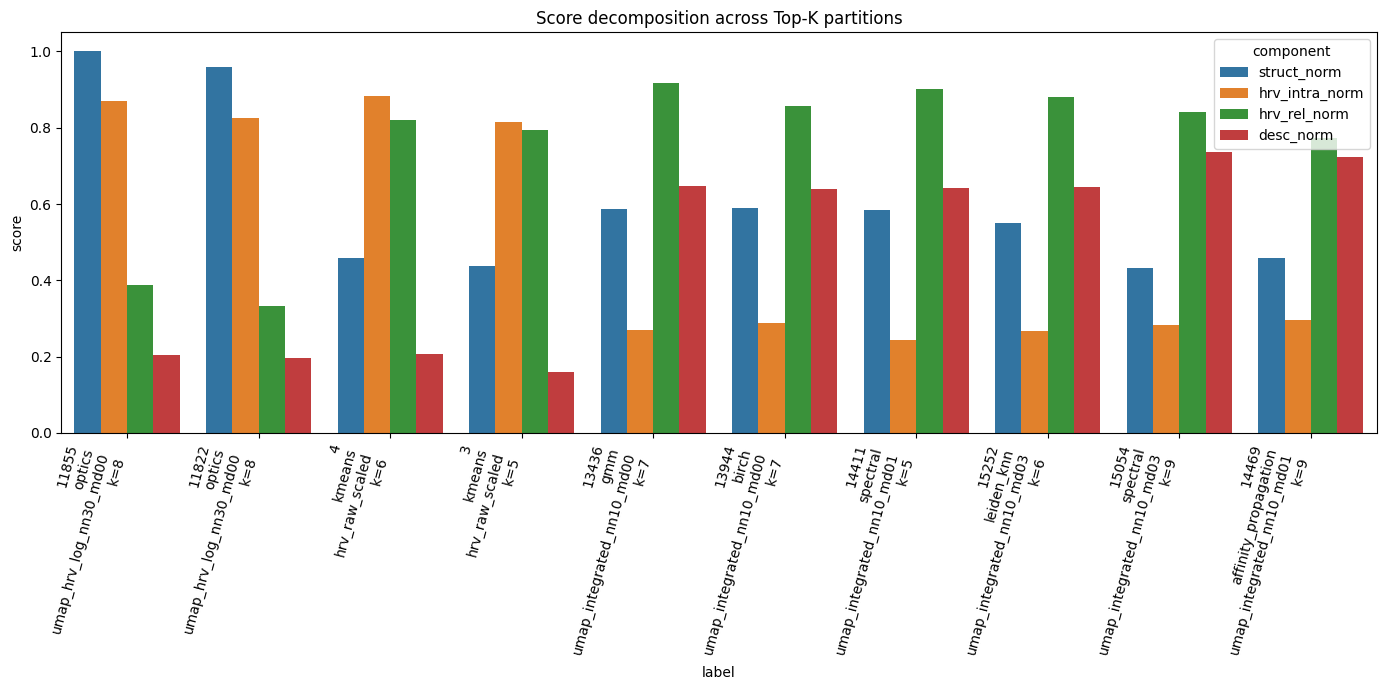

In [23]:
# ============================================
# 23. Plot score decomposition for Top-K
# ============================================

plot_df = topk_df.copy()
plot_df["label"] = plot_df.apply(
    lambda r: f"{int(r['experiment_id'])}\n{r['algorithm']}\n{r['space_name']}\nk={int(r['n_clusters'])}",
    axis=1
)

melt_df = plot_df.melt(
    id_vars=["label"],
    value_vars=["struct_norm", "hrv_intra_norm", "hrv_rel_norm", "desc_norm"],
    var_name="component",
    value_name="score"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=melt_df, x="label", y="score", hue="component")
plt.xticks(rotation=75, ha="right")
plt.title("Score decomposition across Top-K partitions")
plt.tight_layout()
plt.show()

In [24]:
# ============================================
# 24. Cluster size profile for one selected partition
# ============================================

def get_cluster_size_table(experiment_id: int) -> pd.DataFrame:
    labels = load_labels_for_experiment(experiment_id)
    counts = get_cluster_counts(labels.values)
    out = counts.rename_axis("cluster").reset_index(name="n")
    out["fraction"] = out["n"] / out["n"].sum()
    return out.sort_values("n", ascending=False).reset_index(drop=True)

selected_exp = int(topk_df.iloc[0]["experiment_id"])
size_table = get_cluster_size_table(selected_exp)
size_table

,cluster,n,fraction
0,4,64,0.207120
1,1,48,0.155340
2,3,47,0.152104
3,0,34,0.110032
4,5,32,0.103560
5,6,29,0.093851
6,2,28,0.090615
7,7,27,0.087379


In [25]:
# ============================================
# 25. HRV median profiles for one selected partition
# ============================================

def get_cluster_profile_table(experiment_id: int, variables: list) -> pd.DataFrame:
    labels = load_labels_for_experiment(experiment_id)
    tmp = eval_df.copy()
    tmp["cluster"] = labels.values
    tmp = tmp.loc[tmp["cluster"] != -1].copy()

    prof = tmp.groupby("cluster")[variables].median().reset_index()
    return prof

selected_exp = int(topk_df.iloc[0]["experiment_id"])
profile_table = get_cluster_profile_table(selected_exp, HRV_VARS)
profile_table

,cluster,t2m_pre_mean_rr,t2m_pre_mean_hr,t2m_pre_sdnn,t2m_pre_rmssd,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf
0,0,868.5,67.0,278.0,21.5,357.0,514.0,102.5
1,1,881.5,67.0,210.5,24.6,225.5,167.5,34.5
2,2,824.0,73.0,209.0,13.7,71.5,270.5,86.0
3,3,828.0,72.0,154.0,18.0,165.0,74.0,14.0
4,4,763.0,79.0,89.0,6.8,16.0,38.5,10.0
5,5,726.5,81.5,88.0,6.8,174.0,762.5,220.0
6,6,955.0,63.0,18.1,16.9,479.0,125.0,24.0
7,7,716.0,84.0,8.7,6.0,16.0,40.0,10.0


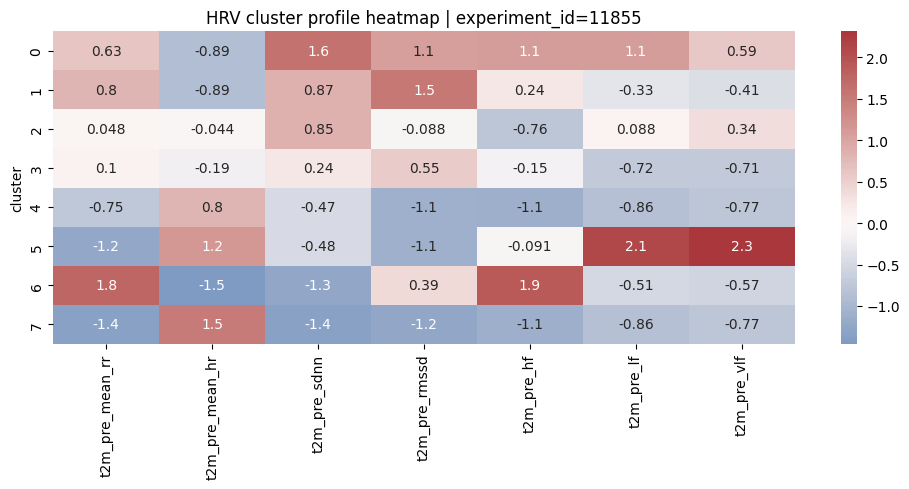

In [26]:
# ============================================
# 26. Heatmap of HRV medians by cluster
# ============================================

profile_table = get_cluster_profile_table(selected_exp, HRV_VARS).set_index("cluster")

# z-score por variable para visualizar patrones relativos
profile_z = profile_table.apply(lambda col: (col - col.mean()) / col.std(ddof=0) if col.std(ddof=0) > 0 else 0.0)

plt.figure(figsize=(10, 5))
sns.heatmap(profile_z, annot=True, cmap="vlag", center=0)
plt.title(f"HRV cluster profile heatmap | experiment_id={selected_exp}")
plt.tight_layout()
plt.show()

In [27]:
# ============================================
# 27. Compare selected vs non-selected candidates
# ============================================

score_df["is_topk"] = score_df["experiment_id"].isin(topk_df["experiment_id"])

compare_cols = [
    "S_primary", "S_struct", "S_hrv_intra_raw", "S_hrv_rel_raw", "S_desc_raw",
    "n_clusters", "noise_fraction", "min_cluster_size", "max_cluster_size",
    "silhouette", "davies_bouldin", "calinski_harabasz"
]

summary_compare = score_df.groupby("is_topk")[compare_cols].agg(["mean", "median"])
summary_compare

S_primary            S_struct           S_hrv_intra_raw           \
             mean    median      mean    median            mean   median   
is_topk                                                                    
False    0.448330  0.451570  0.409802  0.416659        0.101966  0.08985   
True     0.573942  0.550873  0.475289  0.445455        0.201506  0.09282   

        S_hrv_rel_raw           S_desc_raw           n_clusters         \
                 mean    median       mean    median       mean median   
is_topk                                                                  
False        0.831511  0.833064  -0.016282  0.065295   6.966068    7.0   
True         0.888215  0.924394   0.018659  0.118934   7.000000    7.0   

        noise_fraction        min_cluster_size        max_cluster_size         \
                  mean median             mean median             mean median   
is_topk                                                                         
False         0.042462    0.0        43.992761   40.0       128.575328  112.0   
True          0.082453    0.0        37.900000   39.5       111.600000  104.0   

        silhouette           davies_bouldin           calinski_harabasz  \
              mean    median           mean    median              mean   
is_topk                                                                   
False     0.403319  0.414594       0.872872  0.779841       1134.598379   
True      0.448303  0.424322       0.778370  0.770732       1961.698998   

                     
             median  
is_topk              
False    631.984020  
True     635.469423

In [28]:
# ============================================
# 28. Export final tables
# ============================================

OUT_DIR = BASE_DIR / "selection_method_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

score_df.to_csv(OUT_DIR / "all_scored_partitions.csv", index=False)
topk_df.to_csv(OUT_DIR / "topk_selected_partitions.csv", index=False)
topk_analysis.to_csv(OUT_DIR / "topk_selected_partitions_detailed.csv", index=False)

print("Saved to", OUT_DIR.resolve())

Saved to /home/david/Desktop/colabs/nunez_cristian_colabs/HRV_analysis/results/selection_method_outputs


In [29]:
# ============================================
# 29. Optional diagnostic table of failed partitions
# ============================================

if failed:
    failed_df = pd.DataFrame(failed, columns=["experiment_id", "error"])
    failed_df.to_csv(OUT_DIR / "failed_partition_evaluations.csv", index=False)
    failed_df.head(20)
else:
    print("No failed partition evaluations.")

No failed partition evaluations.


In [30]:
# ============================================
# 30. Final concise report
# ============================================

report = {
    "n_total_experiments": len(results_df),
    "n_after_hard_filters": int(struct_df.shape[0]),
    "n_scored_partitions": int(score_df.shape[0]),
    "n_topk": int(topk_df.shape[0]),
    "top_algorithms": topk_df["algorithm"].value_counts().to_dict(),
    "top_families": topk_df["family"].value_counts().to_dict(),
    "top_spaces": topk_df["space_name"].value_counts().to_dict(),
    "top_k_values": topk_df["n_clusters"].value_counts().to_dict(),
}

pd.Series(report)

n_total_experiments                                                 24168
n_after_hard_filters                                                 6641
n_scored_partitions                                                  6641
n_topk                                                                 10
top_algorithms          {'optics': 2, 'kmeans': 2, 'spectral': 2, 'gmm...
top_families            {'density-based': 2, 'centroid-based': 2, 'gra...
top_spaces              {'umap_hrv_log_nn30_md00': 2, 'hrv_raw_scaled'...
top_k_values                               {8: 2, 6: 2, 5: 2, 7: 2, 9: 2}
dtype: object